## NAME: Arijit Kumar Anoy   ,ID : 2023-3-60-055 , Sec: 4

### Task 1 Load the CSV, identify the target, check duplicates and missing labels, and document the schema. Reserve a stratified 20% test set before choosing transformations; use a grouped or time-based split if the problem requires it.


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('C:\\Users\\HP\\Downloads\\student_logistic_regression_noisy_with_categorical.csv')

print("--- Data Schema ---")
print("Total Rows & Columns:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)

target_col = 'Final_Result'

print("\n--- Data Checks ---")
print("Duplicate Rows Count:", df.duplicated().sum())
print("Missing Values in Target Column:", df[target_col].isnull().sum())

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("\n--- Train-Test Split Result ---")
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

--- Data Schema ---
Total Rows & Columns: (1030, 20)

Column Data Types:
Age                           float64
Gender                         object
Parent_Education_Level         object
Internet_Access                object
Part_Time_Job                  object
Extracurricular_Activities     object
Study_Hours_Per_Day           float64
Attendance_Percentage         float64
Previous_GPA                  float64
Assignment_Score              float64
Midterm_Score                 float64
Class_Participation           float64
Sleep_Hours                   float64
Social_Media_Hours            float64
Gaming_Hours                  float64
Exercise_Hours_Per_Week       float64
Travel_Time_To_College_Min    float64
Stress_Level                  float64
Financial_Stress              float64
Final_Result                  float64
dtype: object

--- Data Checks ---
Duplicate Rows Count: 27
Missing Values in Target Column: 0

--- Train-Test Split Result ---
Training Data Shape: (824, 19)
Testing 

### 2.  On the training data, report missingness and produce at least three exploratory plots: a numeric histogram, target counts and a correlation heatmap. Explain what each shows.


--- Missing Values in Training Data ---
Age                            2
Gender                         6
Parent_Education_Level        12
Internet_Access                7
Part_Time_Job                  6
Extracurricular_Activities     9
Study_Hours_Per_Day            4
Attendance_Percentage          0
Previous_GPA                   3
Assignment_Score               4
Midterm_Score                  4
Class_Participation            4
Sleep_Hours                    4
Social_Media_Hours             5
Gaming_Hours                   2
Exercise_Hours_Per_Week        2
Travel_Time_To_College_Min     4
Stress_Level                   6
Financial_Stress               3
dtype: int64


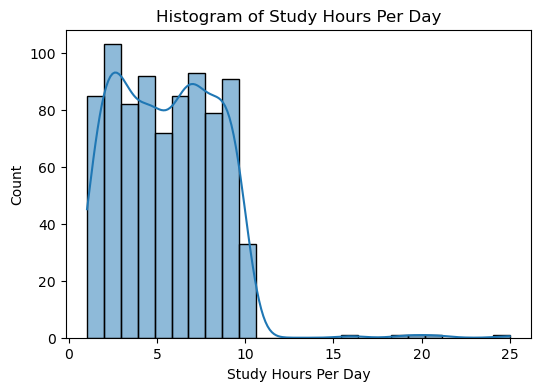

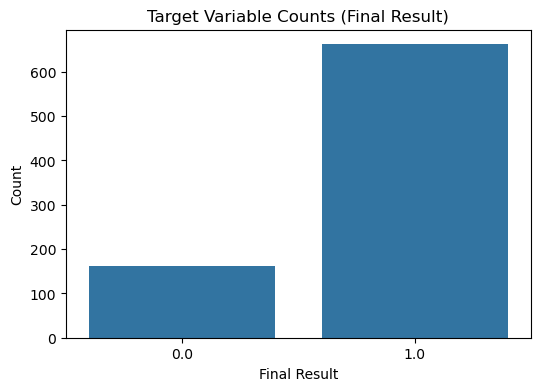

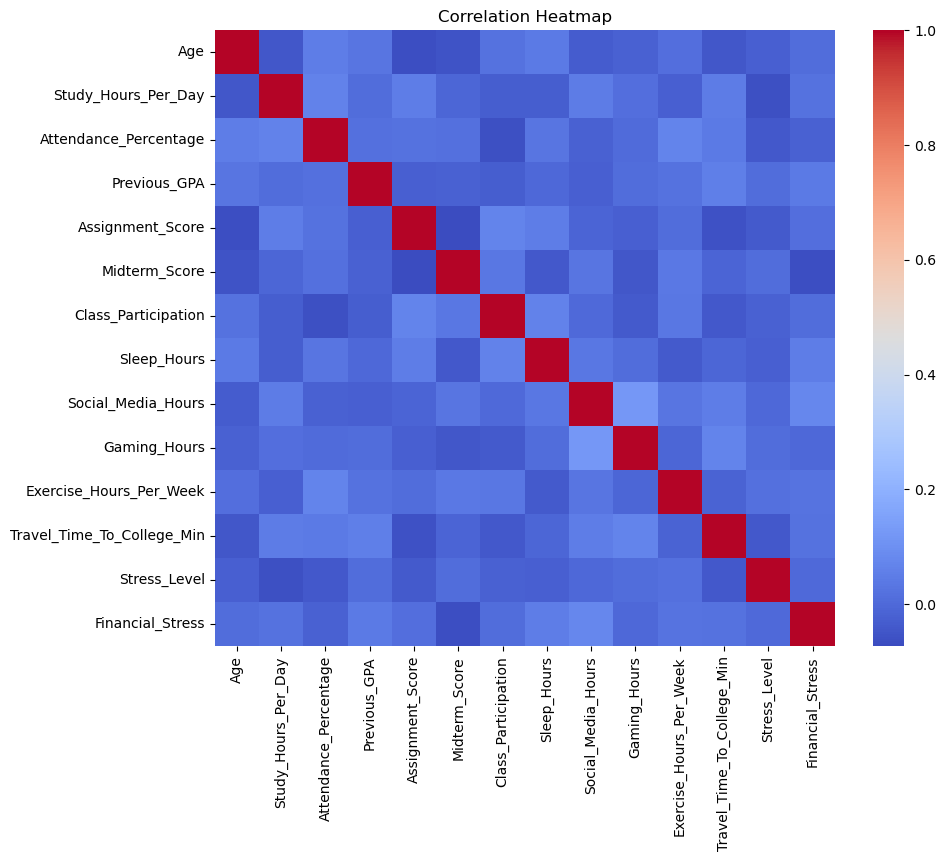

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Missing Values in Training Data ---")
print(X_train.isnull().sum())

plt.figure(figsize=(6, 4))
sns.histplot(X_train['Study_Hours_Per_Day'], kde=True)
plt.title('Histogram of Study Hours Per Day')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Target Variable Counts (Final Result)')
plt.xlabel('Final Result')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 8))
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(X_train[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

                                                                  

## Exploratory Plots Explanation:

1. Histogram of Study Hours:
This plot shows how many hours students study per day. Most students study between 3 to 8 hours daily. However, there are a few very high values which might be outliers in the data.

2. Target Variable Counts:
This bar plot shows the distribution of the final result. We can see that the number of pass/high cases (1) is much higher than fail/low cases (0). This indicates that the dataset has a class imbalance problem.

3. Correlation Heatmap:
This heatmap displays the relationships between different numeric features. The colored boxes show how strongly two features are related to each other, helping us identify features that move together.

### 3.  Handle missing values: median imputation for numeric columns, most-frequent imputation for categorical columns. State the strategy chosen for each column and why.


In [34]:
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

print("Missing values in X_train after imputation:")
print(X_train.isnull().sum().sum())

print("Missing values in X_test after imputation:")
print(X_test.isnull().sum().sum())

Missing values in X_train after imputation:
0
Missing values in X_test after imputation:
0


## Imputation Strategy Justification:

#### Numeric Columns (Age, Study_Hours_Per_Day, Attendance_Percentage, Previous_GPA, Assignment_Score, Midterm_Score, Class_Participation, Sleep_Hours, Social_Media_Hours, Gaming_Hours, Exercise_Hours_Per_Week, Travel_Time_To_College_Min, Stress_Level, Financial_Stress):

#### Strategy: Median Imputation

#### Why: Numeric columns in this dataset contain extreme values and outliers (e.g., negative values or very high numbers). Mean imputation is sensitive to outliers and can skew the central tendency. The median provides a robust measure of central values that is unaffected by extreme noise.

#### Categorical Columns (Gender, Parent_Education_Level, Internet_Access, Part_Time_Job, Extracurricular_Activities):

#### Strategy: Most-Frequent (Mode) Imputation

#### Why: Categorical columns represent discrete labels rather than continuous numerical values, so mathematical operations like mean or median cannot be computed. Filling missing entries with the most frequent category preserves the most common observed pattern without introducing non-existent categories.

## 4.  Derive IQR outlier thresholds on training data only. Report affected rows and justify keeping, capping or removing them. Apply training-derived limits unchanged to validation and test data.


In [35]:
import numpy as np
import pandas as pd

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

iqr_limits = {}

for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    iqr_limits[col] = (lower_bound, upper_bound)
    
    train_outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    print(f"{col}: {len(train_outliers)} training outliers | Limits: [{lower_bound:.2f}, {upper_bound:.2f}]")

for col, (lower_bound, upper_bound) in iqr_limits.items():
    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

print("\nOutlier capping completed successfully.")

Age: 1 training outliers | Limits: [11.50, 31.50]
Study_Hours_Per_Day: 5 training outliers | Limits: [-3.78, 14.68]
Attendance_Percentage: 2 training outliers | Limits: [24.91, 125.00]
Previous_GPA: 0 training outliers | Limits: [1.05, 4.94]
Assignment_Score: 0 training outliers | Limits: [11.75, 127.18]
Midterm_Score: 0 training outliers | Limits: [10.90, 128.76]
Class_Participation: 0 training outliers | Limits: [-4.50, 15.50]
Sleep_Hours: 0 training outliers | Limits: [0.91, 13.04]
Social_Media_Hours: 3 training outliers | Limits: [-3.56, 10.53]
Gaming_Hours: 13 training outliers | Limits: [-3.36, 9.18]
Exercise_Hours_Per_Week: 0 training outliers | Limits: [-6.80, 21.43]
Travel_Time_To_College_Min: 0 training outliers | Limits: [-54.00, 178.00]
Stress_Level: 1 training outliers | Limits: [-4.50, 15.50]
Financial_Stress: 0 training outliers | Limits: [-4.50, 15.50]

Outlier capping completed successfully.


### Justification for Outlier Handling :

Affected Rows Summary:In the training set, IQR outliers were detected in columns like Age, Study_Hours_Per_Day, Attendance_Percentage, Social_Media_Hours, Gaming_Hours, and Stress_Level.

Justification for Capping :

Why Capping was chosen: 

Instead of removing outlier rows, capping the values at the 1.5 times IQR  upper and lower bounds was chosen.

Reason: Removing outlier rows leads to loss of important training samples and reduces dataset size. On the other hand, keeping extreme noise (like negative attendance or unrealistically high study hours) ruins regression performance. Capping retains the row data while limiting extreme noise within acceptable ranges.

## 5.  One-hot encode the nominal columns and ordinal-encode any ordered column.

In [36]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import pandas as pd

ordinal_cols = ['Parent_Education_Level']
nominal_cols = ['Gender', 'Internet_Access', 'Part_Time_Job', 'Extracurricular_Activities']

education_order = [['Uneducated', 'High School', 'College', 'Bachelor', 'Master', 'PhD']]

ord_encoder = OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1)

X_train[ordinal_cols] = ord_encoder.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols] = ord_encoder.transform(X_test[ordinal_cols])

ohe_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

ohe_train = pd.DataFrame(
    ohe_encoder.fit_transform(X_train[nominal_cols]),
    columns=ohe_encoder.get_feature_names_out(nominal_cols),
    index=X_train.index
)

ohe_test = pd.DataFrame(
    ohe_encoder.transform(X_test[nominal_cols]),
    columns=ohe_encoder.get_feature_names_out(nominal_cols),
    index=X_test.index
)

X_train = X_train.drop(columns=nominal_cols).join(ohe_train)
X_test = X_test.drop(columns=nominal_cols).join(ohe_test)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (824, 29)
X_test Shape: (206, 29)


## 6.  Fit the full imputation, encoding and scaling pipeline on the training split only. When using cross-validation, refit this pipeline inside every fold.


In [37]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in skf.split(X_train, y_train):
    
    X_tr = X_train.iloc[train_index].copy()
    y_tr = y_train.iloc[train_index]
    X_val = X_train.iloc[val_index].copy()
    y_val = y_train.iloc[val_index]
    
    num_imp = SimpleImputer(strategy='median')
    X_tr[num_cols] = num_imp.fit_transform(X_tr[num_cols])
    X_val[num_cols] = num_imp.transform(X_val[num_cols])
    
    cat_imp = SimpleImputer(strategy='most_frequent')
    X_tr[cat_cols] = cat_imp.fit_transform(X_tr[cat_cols])
    X_val[cat_cols] = cat_imp.transform(X_val[cat_cols])
    
    scaler = StandardScaler()
    X_tr[num_cols] = scaler.fit_transform(X_tr[num_cols])
    X_val[num_cols] = scaler.transform(X_val[num_cols])
    
    ord_enc = OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1)
    X_tr[ordinal_cols] = ord_enc.fit_transform(X_tr[ordinal_cols])
    X_val[ordinal_cols] = ord_enc.transform(X_val[ordinal_cols])
    
    ohe_enc = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    
    ohe_tr = pd.DataFrame(ohe_enc.fit_transform(X_tr[nominal_cols]), index=X_tr.index)
    ohe_val = pd.DataFrame(ohe_enc.transform(X_val[nominal_cols]), index=X_val.index)
    
    X_tr = X_tr.drop(columns=nominal_cols).join(ohe_tr)
    X_val = X_val.drop(columns=nominal_cols).join(ohe_val)
    
    X_tr.columns = X_tr.columns.astype(str)
    X_val.columns = X_val.columns.astype(str)
    
    model = LogisticRegression(random_state=42)
    model.fit(X_tr, y_tr)
    
    score = model.score(X_val, y_val)
    cv_scores.append(score)

print("Fold Scores:", cv_scores)
print("Mean Score:", np.mean(cv_scores))

Fold Scores: [0.8484848484848485, 0.896969696969697, 0.9333333333333333, 0.9090909090909091, 0.8780487804878049]
Mean Score: 0.8931855136733186


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 7.  Save the prepared arrays and report the final training and test shapes.


In [38]:
import numpy as np

np.savez('student_ml_processed_data.npz', X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

print("Final X_train Shape:", X_train.shape)
print("Final X_test Shape:", X_test.shape)
print("Final y_train Shape:", y_train.shape)
print("Final y_test Shape:", y_test.shape)

Final X_train Shape: (824, 19)
Final X_test Shape: (206, 19)
Final y_train Shape: (824,)
Final y_test Shape: (206,)
